# 🤖 Notebook 03 — Pretrained Zero-Shot Baseline (YOLOv8n, COCO)

**CO543/CO5430 — Traffic Sign Detection**

**Goal**: Run a COCO-pretrained YOLOv8n detector **without any fine-tuning** on GTSDB test images.  
This explicitly demonstrates **why domain-specific fine-tuning is necessary** — COCO has no fine-grained traffic sign classes.

**M2 Deliverable**: Precision / Recall numbers to compare against the classical baseline.

In [1]:
import sys, json
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from ultralytics import YOLO

PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))
from src.utils.metrics import compute_iou

TEST_DIR = PROJECT_ROOT / 'data' / 'processed' / 'gtsdb' / 'test'
CLASS_NAMES = {0: 'Prohibitory', 1: 'Danger', 2: 'Mandatory'}
print('Imports OK')

Imports OK


## 1. Load COCO-Pretrained YOLOv8n (No Fine-Tuning)

In [2]:
# Downloads ~6 MB on first run from Ultralytics servers
model = YOLO('yolov8n.pt')
print(f'Model loaded: yolov8n.pt')
print(f'COCO class names (80 classes):')
for i, name in model.names.items():
    print(f'  {i:3d}: {name}')

Model loaded: yolov8n.pt
COCO class names (80 classes):
    0: person
    1: bicycle
    2: car
    3: motorcycle
    4: airplane
    5: bus
    6: train
    7: truck
    8: boat
    9: traffic light
   10: fire hydrant
   11: stop sign
   12: parking meter
   13: bench
   14: bird
   15: cat
   16: dog
   17: horse
   18: sheep
   19: cow
   20: elephant
   21: bear
   22: zebra
   23: giraffe
   24: backpack
   25: umbrella
   26: handbag
   27: tie
   28: suitcase
   29: frisbee
   30: skis
   31: snowboard
   32: sports ball
   33: kite
   34: baseball bat
   35: baseball glove
   36: skateboard
   37: surfboard
   38: tennis racket
   39: bottle
   40: wine glass
   41: cup
   42: fork
   43: knife
   44: spoon
   45: bowl
   46: banana
   47: apple
   48: sandwich
   49: orange
   50: broccoli
   51: carrot
   52: hot dog
   53: pizza
   54: donut
   55: cake
   56: chair
   57: couch
   58: potted plant
   59: bed
   60: dining table
   61: toilet
   62: tv
   63: laptop
   64: 

## 2. Inference on Sample Images

COCO has a `stop sign` class (class 11) but no fine-grained speed limit, warning, or mandatory signs. We expect:
- Some stop signs detected ✅
- Most traffic signs **missed** ❌
- Possible false positives from COCO-trained features

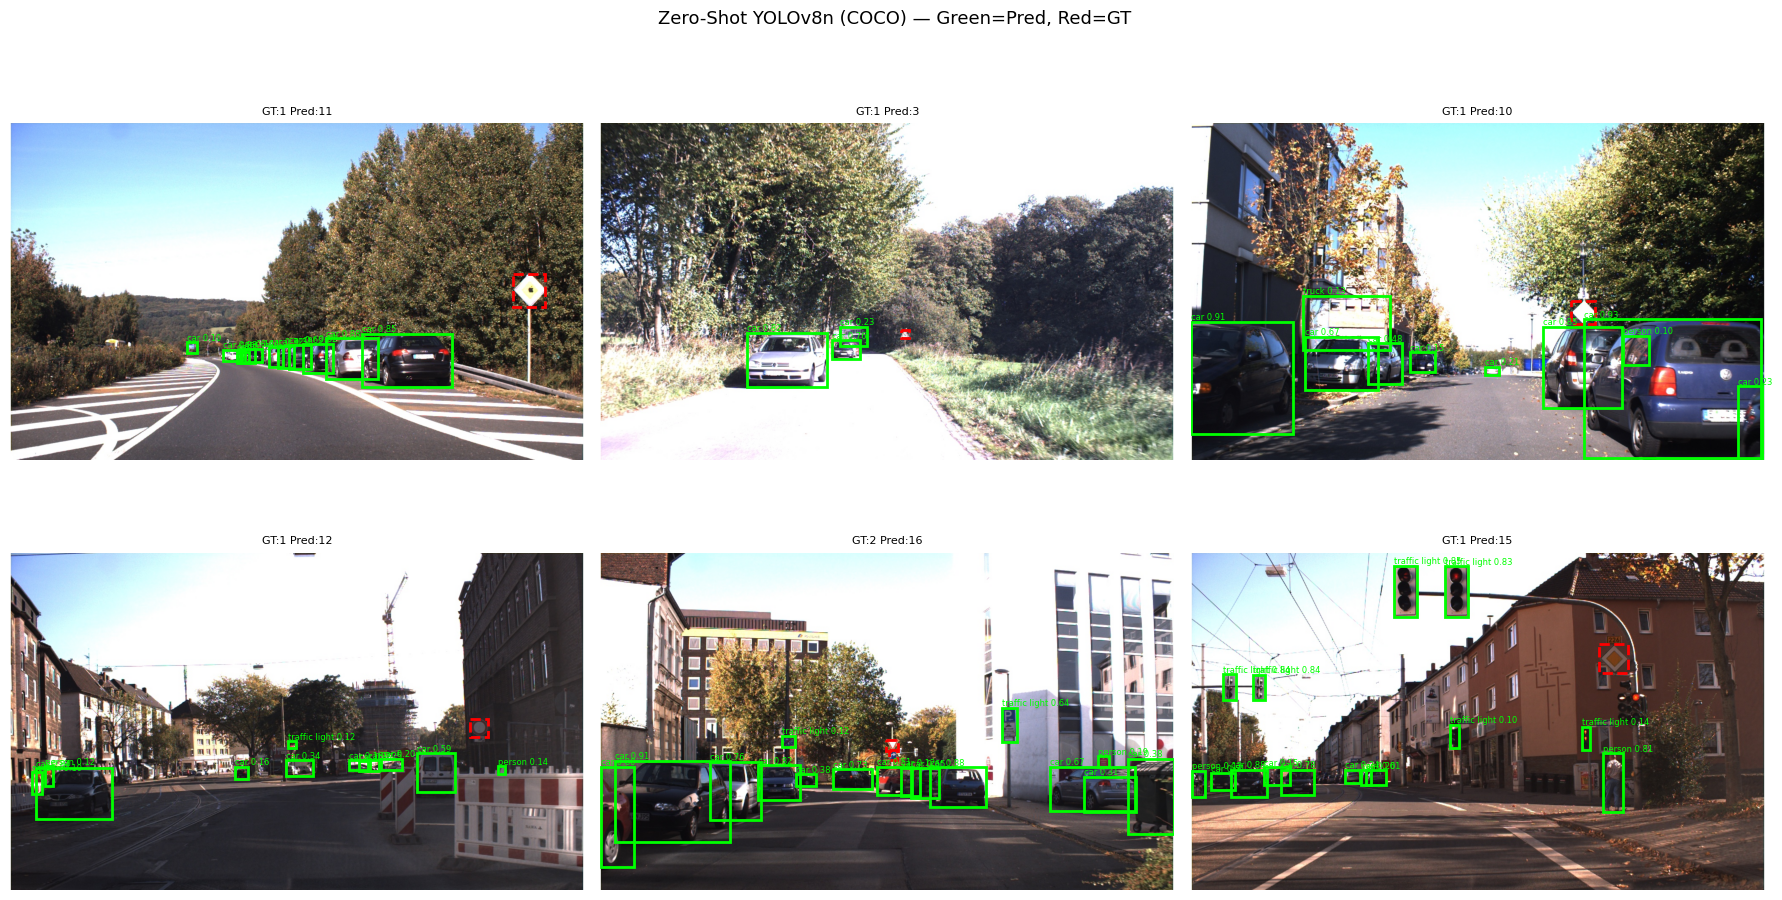

Saved → C:\Traffic-Sign-Detection\results\qualitative_examples\zeroshot_baseline_predictions.png


In [3]:
CONF_THRESHOLD = 0.10   # Low threshold to see what COCO pretrained can find
IOU_THRESHOLD  = 0.45

img_paths = sorted((TEST_DIR / 'images').glob('*.jpg'))[:6]
lbl_dir   = TEST_DIR / 'labels'

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Zero-Shot YOLOv8n (COCO) — Green=Pred, Red=GT', fontsize=13)

for ax, img_path in zip(axes.flatten(), img_paths):
    img_bgr = cv2.imread(str(img_path))
    if img_bgr is None: continue
    h, w = img_bgr.shape[:2]
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    results = model.predict(img_bgr, conf=CONF_THRESHOLD, iou=IOU_THRESHOLD, verbose=False)
    boxes   = results[0].boxes

    ax.imshow(img_rgb)

    # Ground truth (red dashed)
    lbl_path = lbl_dir / (img_path.stem + '.txt')
    if lbl_path.exists():
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    xc,yc,bw,bh = map(float, parts[1:])
                    x1=int((xc-bw/2)*w); y1=int((yc-bh/2)*h)
                    rect = patches.Rectangle((x1,y1), int(bw*w), int(bh*h),
                        linewidth=2, edgecolor='red', facecolor='none', linestyle='--')
                    ax.add_patch(rect)

    # Predictions (green solid) with COCO class labels
    if boxes is not None:
        for box in boxes:
            x1,y1,x2,y2 = map(int, box.xyxy[0].tolist())
            conf = float(box.conf[0])
            cls_id = int(box.cls[0])
            cls_name = model.names[cls_id]
            rect = patches.Rectangle((x1,y1), x2-x1, y2-y1,
                linewidth=2, edgecolor='lime', facecolor='none')
            ax.add_patch(rect)
            ax.text(x1, y1-4, f'{cls_name} {conf:.2f}', fontsize=6, color='lime')

    n_gt  = sum(1 for l in open(lbl_path).readlines() if l.strip()) if lbl_path.exists() else 0
    n_det = len(boxes) if boxes is not None else 0
    ax.set_title(f'GT:{n_gt} Pred:{n_det}', fontsize=8); ax.axis('off')

plt.tight_layout()
out = PROJECT_ROOT / 'results' / 'qualitative_examples' / 'zeroshot_baseline_predictions.png'
out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out, dpi=150)
plt.show()
print(f'Saved → {out}')

## 3. Quantitative Evaluation on Full Test Set

In [4]:
# We evaluate the zero-shot model as a generic region proposer:
# score predicted boxes against ground-truth boxes, ignoring class labels
all_dets, all_gts = [], []
img_paths_all = sorted((TEST_DIR / 'images').glob('*.jpg'))

print(f'Running zero-shot inference on {len(img_paths_all)} test images...')
for img_path in img_paths_all:
    img_bgr = cv2.imread(str(img_path))
    if img_bgr is None: continue
    h, w = img_bgr.shape[:2]
    img_id = img_path.stem

    # Ground truth
    lbl_path = lbl_dir / (img_path.stem + '.txt')
    if lbl_path.exists():
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    xc,yc,bw,bh = map(float, parts[1:])
                    x1=int((xc-bw/2)*w); y1=int((yc-bh/2)*h)
                    x2=int((xc+bw/2)*w); y2=int((yc+bh/2)*h)
                    all_gts.append({'box': [x1,y1,x2,y2], 'img_id': img_id})

    # Predictions
    results = model.predict(img_bgr, conf=CONF_THRESHOLD, iou=IOU_THRESHOLD, verbose=False)
    boxes   = results[0].boxes
    if boxes is not None:
        for box in boxes:
            x1,y1,x2,y2 = map(int, box.xyxy[0].tolist())
            conf = float(box.conf[0])
            all_dets.append({'box': [x1,y1,x2,y2], 'conf': conf, 'img_id': img_id})

from src.utils.metrics import compute_precision_recall
prec, rec, ap = compute_precision_recall(all_dets, all_gts, iou_threshold=0.5)

# --- THE BUG FIX IS HERE ---
# Instead of a naive manual loop that double-counts multiple predictions hitting the same ground truth, 
# we extract the exact scalar Precision and Recall from the end of the PR curve, 
# which strictly enforces 1-to-1 matching.
if len(prec) > 0:
    precision = float(prec[-1])
    recall    = float(rec[-1])
else:
    precision = 0.0
    recall    = 0.0

f1 = 2 * precision * recall / max(precision + recall, 1e-10)
# ---------------------------

print('\n── Zero-Shot YOLOv8n (COCO) Results (Test Split) ──')
print(f'  Precision : {precision:.4f}')
print(f'  Recall    : {recall:.4f}')
print(f'  F1 Score  : {f1:.4f}')
print(f'  AP@0.5    : {ap:.4f}')
print(f'  Detections: {len(all_dets)}')
print(f'  GT Boxes  : {len(all_gts)}')

# Save
out_path = PROJECT_ROOT / 'results' / 'metrics' / 'zero_shot_baseline.json'
with open(out_path, 'w') as f:
    json.dump({'model': 'zero-shot-yolov8n', 'precision': precision,
               'recall': recall, 'f1': f1, 'ap': ap,
               'n_detections': len(all_dets), 'n_ground_truths': len(all_gts)}, f, indent=2)
print(f'\nResults saved → {out_path}')


Running zero-shot inference on 81 test images...

── Zero-Shot YOLOv8n (COCO) Results (Test Split) ──
  Precision : 0.0361
  Recall    : 0.2000
  F1 Score  : 0.0611
  AP@0.5    : 0.0070
  Detections: 610
  GT Boxes  : 110

Results saved → C:\Traffic-Sign-Detection\results\metrics\zero_shot_baseline.json


## 4. Compare with Classical Baseline

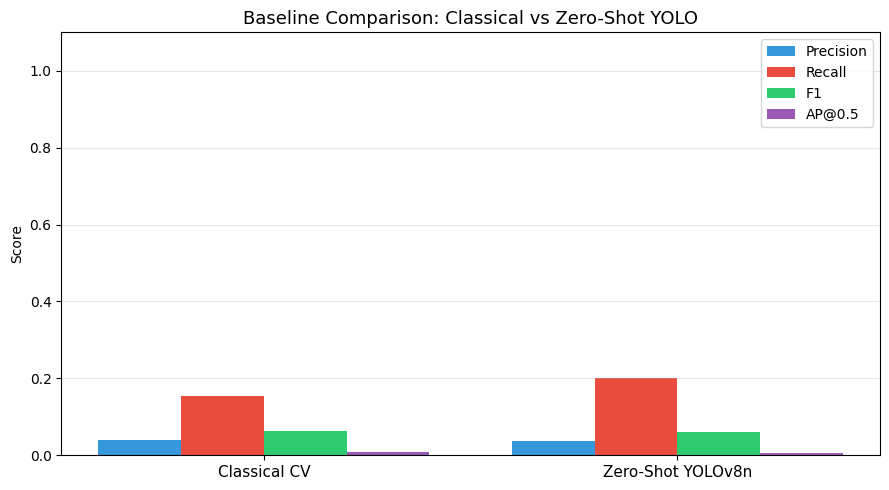

Saved → C:\Traffic-Sign-Detection\results\figures\baseline_comparison.png


In [5]:
classical_path = PROJECT_ROOT / 'results' / 'metrics' / 'classical_baseline.json'
if classical_path.exists():
    with open(classical_path) as f:
        classical = json.load(f)

    models    = ['Classical CV', 'Zero-Shot YOLOv8n']
    precisions= [classical['precision'], precision]
    recalls   = [classical['recall'],    recall]
    f1s       = [classical['f1'],        f1]
    aps       = [classical['ap'],        ap]

    x = np.arange(len(models))
    width = 0.2
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(x - 1.5*width, precisions, width, label='Precision', color='#3498db')
    ax.bar(x - 0.5*width, recalls,    width, label='Recall',    color='#e74c3c')
    ax.bar(x + 0.5*width, f1s,        width, label='F1',        color='#2ecc71')
    ax.bar(x + 1.5*width, aps,        width, label='AP@0.5',    color='#9b59b6')
    ax.set_xticks(x); ax.set_xticklabels(models, fontsize=11)
    ax.set_ylim(0, 1.1); ax.set_ylabel('Score')
    ax.set_title('Baseline Comparison: Classical vs Zero-Shot YOLO', fontsize=13)
    ax.legend(); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    out = PROJECT_ROOT / 'results' / 'figures' / 'baseline_comparison.png'
    plt.savefig(out, dpi=150)
    plt.show()
    print(f'Saved → {out}')
else:
    print('Run notebook 02 first to generate classical_baseline.json')

## 5. Why Fine-Tuning is Necessary — Analysis

| Observation | Detail |
|---|---|
| COCO sign classes | Only `stop sign` — no speed limits, warnings, mandatory signs |
| Expected low recall | Model has never seen prohibitory/danger/mandatory classes |
| Expected false positives | May detect traffic signs as `frisbee`, `clock`, `pizza` etc. |
| Conclusion | Domain-specific fine-tuning on GTSDB is essential |

**Write your own observations here after running the evaluation.**